# Testing for the 1DInt Method For Diploids and Autotetraploids

In [3]:
import numpy as np
import dadi 
from matplotlib import pyplot as plt
import dadi.Polyploidy.Integration as PolyInt
import dadi.Polyploidy.wrightfisher as WF 
import dadi.Polyploidy as Polyploidy
import time

## Tests against dadi

### Test Accuracy of the Int1D Integration for Diploids against dadi
Here, we want to ensure that the results from the Int1D integration are the same as the results from dadi.

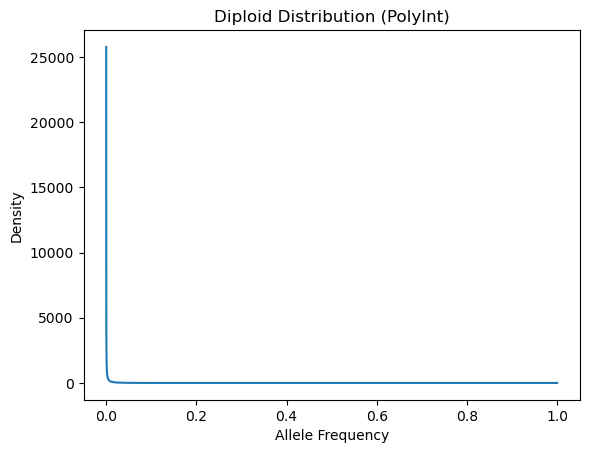

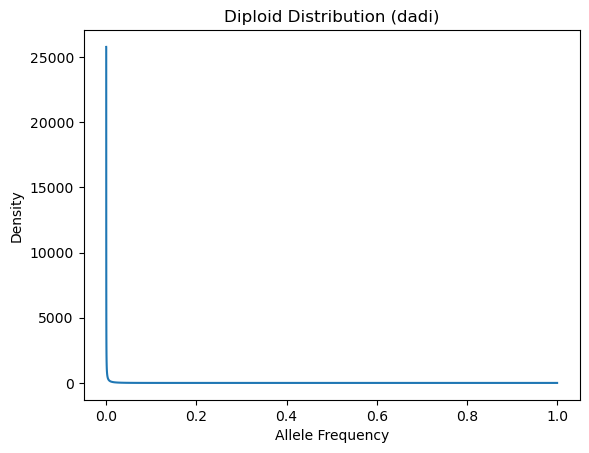

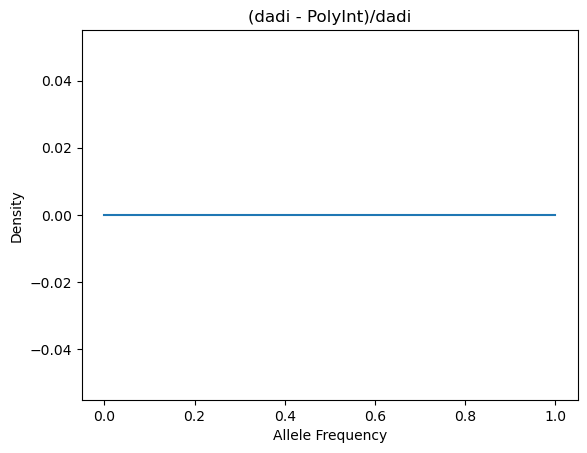

In [2]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)

ploidyflag = PolyInt.PloidyType.DIPLOID
T = 10
gamma = -10
h = 0.5
sel_dict = {'gamma': gamma, 'h': h}
nu = 1.5
nu_func = lambda t: np.exp(np.log(nu)*t/T)
phi_poly = PolyInt.one_pop(phi.copy(), xx, T=T, ploidyflag=ploidyflag, sel_dict=sel_dict, theta0=1, nu=nu_func)

plt.plot(xx, phi_poly)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('Diploid Distribution (PolyInt)')
plt.show()

phi_dadi = dadi.Integration.one_pop(phi.copy(), xx, T=T, theta0=1, gamma=gamma, h=h, nu=nu_func)

plt.plot(xx, phi_dadi)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('Diploid Distribution (dadi)')
plt.show()

plt.plot(xx, (phi_poly - phi_dadi)/phi_dadi)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('(dadi - PolyInt)/dadi')
plt.show()

### Test Int1D for autotetraploids under = gammas, additivity, and integrated twice as long 

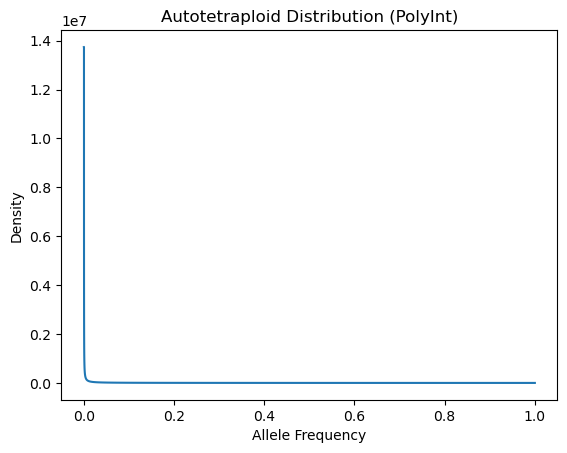

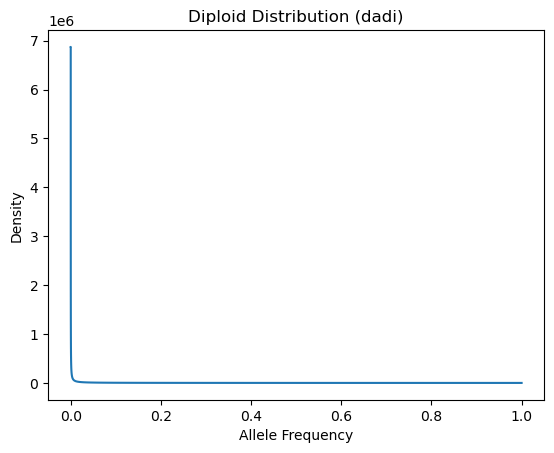

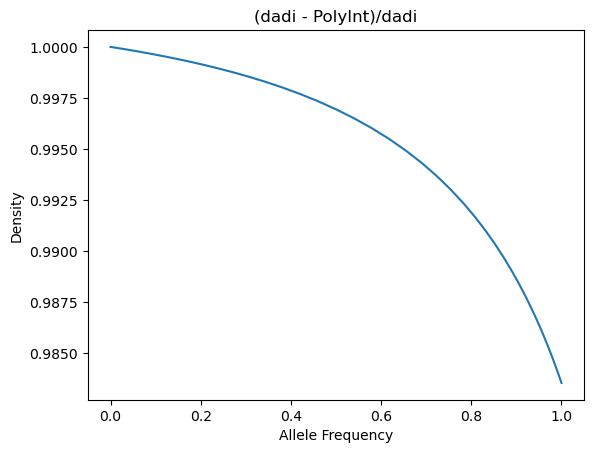

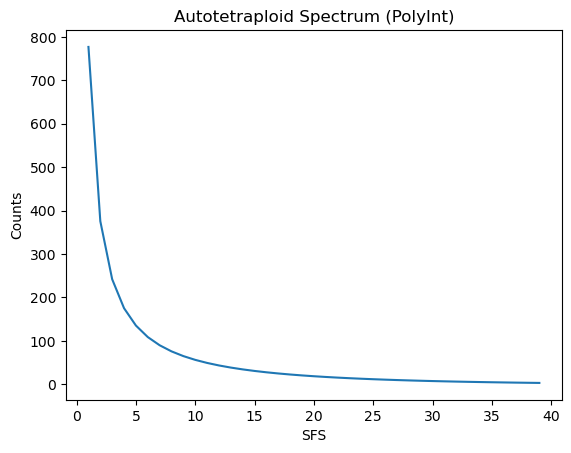

In [3]:
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)

autoflag = PolyInt.PloidyType.AUTO
T = 1
gamma = 0
h = 0.5
auto_dict = {'gamma': gamma}
nu = 1
nu_func = lambda t: np.exp(np.log(nu)*t/T)
nu_func_auto = lambda t: np.exp(np.log(nu)*t/(2*T))

phi_poly = PolyInt.one_pop(phi.copy(), xx, T=2*T, ploidyflag=autoflag, sel_dict=auto_dict, theta0=400, nu=nu_func_auto)


plt.plot(xx, phi_poly)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('Autotetraploid Distribution (PolyInt)')
plt.show()

phi_dadi = dadi.Integration.one_pop(phi.copy(), xx, T=T, theta0=400, gamma=gamma, h=h, nu=nu_func)


plt.plot(xx, phi_dadi)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('Diploid Distribution (dadi)')
plt.show()

plt.plot(xx, (phi_poly - phi_dadi)/phi_dadi)
plt.xlabel('Allele Frequency')
plt.ylabel('Density')
plt.title('(dadi - PolyInt)/dadi')
plt.show()

spectrum_poly = dadi.Spectrum.from_phi(phi_poly, (40,), (xx,))
plt.plot(spectrum_poly)
plt.xlabel('SFS')
plt.ylabel('Counts')
plt.title('Autotetraploid Spectrum (PolyInt)')
plt.show()



## Test Accuracy of PolyInt for Autotetraploids against WF Simulations

Mean final allele frequency: 0.23505886195544667
Variance of final allele frequency: 0.04299684381767029


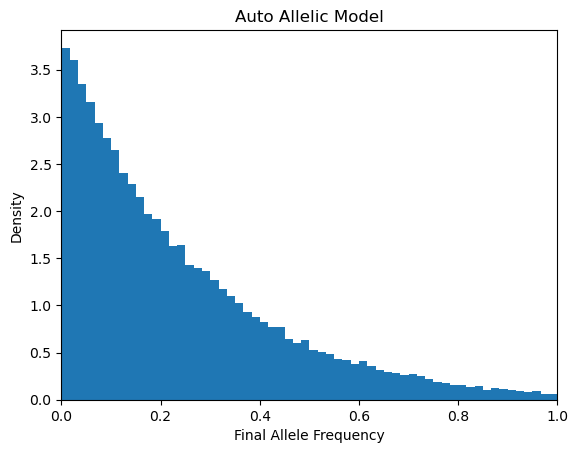

Mean: 0.2347557742210879
Variance: 0.04323453376769402


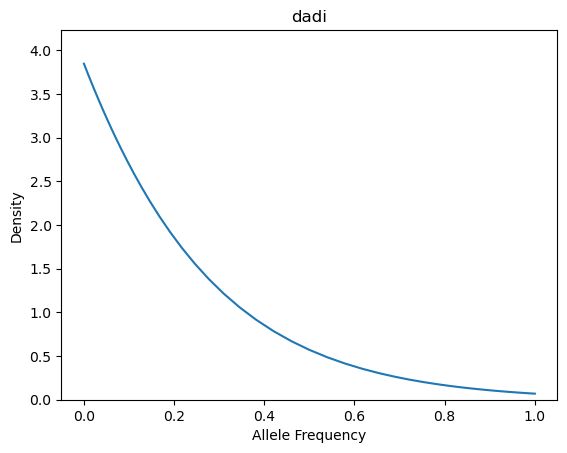

In [4]:
# Test Autotetraploid Integrations Against WF Model
# set up parameters, grid, and phi
xx = dadi.Numerics.default_grid(pts=101)
# Dirac delta type phi
phi = np.zeros_like(xx)
phi[50] = 1

T = 1
gamma = -4

autoflag = PolyInt.PloidyType.AUTO
sel_dict = {'gamma': gamma}
sel=autoflag.pack_sel_params(sel_dict)

# WF MODEL
WF_auto = WF.auto_allelic_WF(N=1000, T=T, gamma1=sel[0], gamma2=sel[1], gamma3=sel[2], gamma4=sel[3], init_q = np.full(100000, .5), replicates = 100000)
# extract final frequencies and mask/remove 0 and 1 entries
allele_polymorphic = WF.mask(WF_auto)

# Compute and print mean and variance
print(f"Mean final allele frequency: {np.mean(allele_polymorphic)}")
print(f"Variance of final allele frequency: {np.var(allele_polymorphic)}")

# Plot histogram of final allele frequencies
plt.hist(allele_polymorphic, bins = 60, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Auto Allelic Model')
plt.xlim(0, 1)
plt.show()

# DADI DIFFUSION MODELS
phi_dadi = PolyInt.one_pop(phi, xx, T=T, ploidyflag=autoflag, sel_dict=sel_dict, theta0=0)
# plot and print mean and variance
WF.summarize_phi(phi_dadi, xx, 'dadi')


### Validate the Variable Population Size WF Simulation Against dadi

Mean final allele frequency: 0.2590349016712531
Variance of final allele frequency: 0.05107551387237159


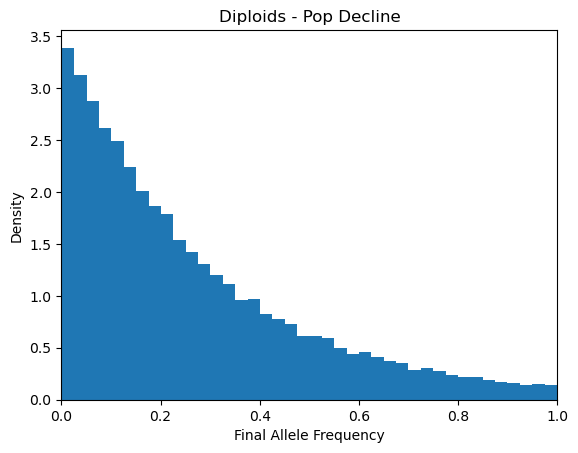

Mean: 0.256095742540784
Variance: 0.05061076388901457


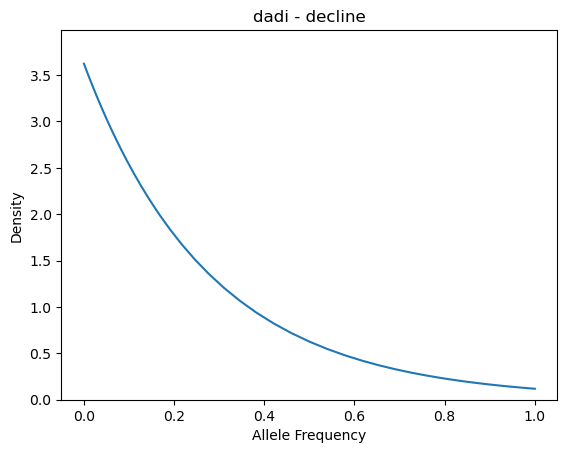

Mean final allele frequency: 0.11187684191631116
Variance of final allele frequency: 0.011365679188471998


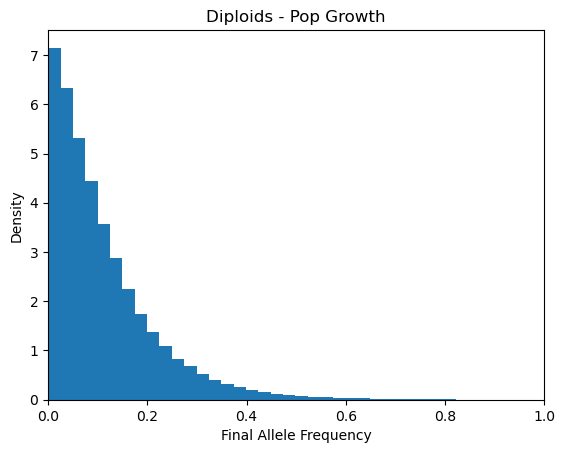

Mean: 0.11129657099494698
Variance: 0.011090457164621734


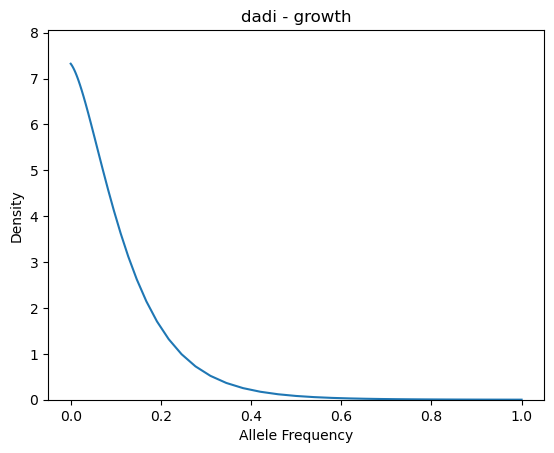

In [5]:
T = .5
N = 1000
gamma = -5
h = 0.5
nu = 0.5
nu_func = lambda t: np.exp(np.log(nu)*t/T)
dipflag = PolyInt.PloidyType.DIPLOID
sel_dict = {'gamma': gamma, 'h': h}
replicates = 100000
init_q = np.full(replicates, 0.5)

# population decline
dip_allele = WF.dip_allelic_WF(N=N, T=T, gamma=gamma, init_q=init_q, nu=nu_func, h=h, replicates=replicates)
dip_allele = WF.mask(dip_allele)

# Compute and print mean and variance
print(f"Mean final allele frequency: {np.mean(dip_allele)}")
print(f"Variance of final allele frequency: {np.var(dip_allele)}")

# Plot histogram of final allele frequencies
plt.hist(dip_allele, bins = 40, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Diploids - Pop Decline')
plt.xlim(0, 1)
plt.show()

xx = dadi.Numerics.default_grid(pts=101)
phi = np.zeros_like(xx)
phi[50] = 1000

phi = dadi.Integration.one_pop(phi.copy(), xx, T=T, theta0=0, gamma=gamma, h=h, nu=nu_func)

WF.summarize_phi(phi, xx, 'dadi - decline')

# population growth
nu = 5
nu_func = lambda t: np.exp(np.log(nu)*t/T)

dip_allele = WF.dip_allelic_WF(N=N, T=T, gamma=gamma, init_q=init_q, nu=nu_func, h=h, replicates=replicates)
dip_allele = WF.mask(dip_allele)

# Compute and print mean and variance
print(f"Mean final allele frequency: {np.mean(dip_allele)}")
print(f"Variance of final allele frequency: {np.var(dip_allele)}")

# Plot histogram of final allele frequencies
plt.hist(dip_allele, bins = 40, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('Diploids - Pop Growth')
plt.xlim(0, 1)
plt.show()

xx = dadi.Numerics.default_grid(pts=101)
phi = np.zeros_like(xx)
phi[50] = 1000

phi = dadi.Integration.one_pop(phi.copy(), xx, T=T, theta0=0, gamma=gamma, h=h, nu=nu_func)

WF.summarize_phi(phi, xx, 'dadi - growth')

WF AUTOHEX SUMMARY
Mean final allele frequency: 0.45890987142264617
Variance of final allele frequency: 0.009233016133388018


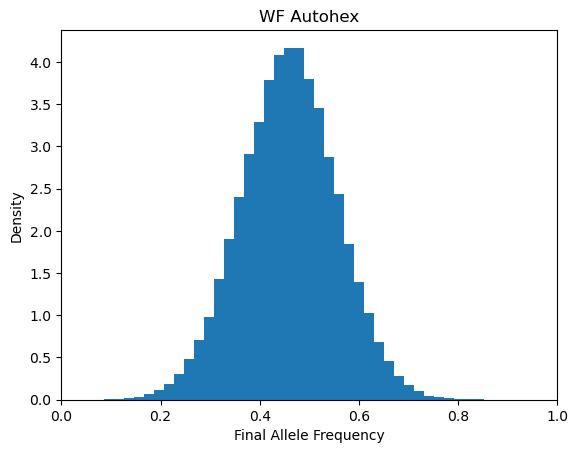

Mean: 0.4589670684868387
Variance: 0.009231510644610197


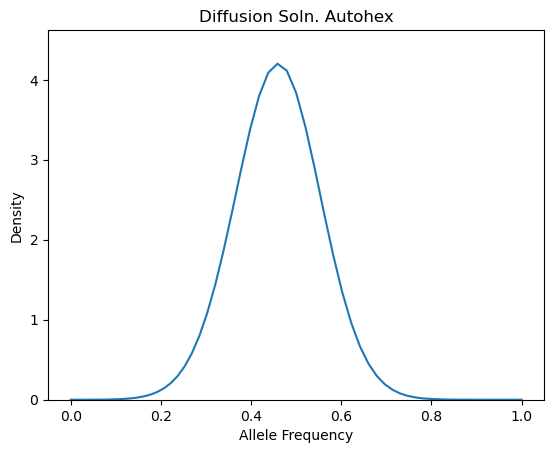

In [6]:
# test autohexaploids
T = .1
N = 1000
gamma = -5
h = 0.5
nu = .4
nu_func = lambda t: np.exp(np.log(nu)*t/T)
autohexflag = PolyInt.PloidyType.AUTOHEX
sel_dict = {'gamma1': -10, 'gamma2': -2, 'gamma3': -2, 'gamma4': -5, 'gamma5': -13, 'gamma6': -7}
sel_vec = autohexflag.pack_sel_params(sel_dict)
replicates = 100000
init_q = np.full(replicates, 0.5)

xx = dadi.Numerics.default_grid(pts=101, crwd=4)
phi = np.zeros_like(xx)
phi[50] = 1000

# population decline
# WF
autohex_wf = WF.autohex_allelic_WF(N=N, T=T, init_q=init_q, s=sel_vec, nu=nu_func, replicates=replicates)
autohex_wf = WF.mask(autohex_wf)
# diffusion
autohex_diff = PolyInt.one_pop(phi, xx, T, nu_func, sel_dict, autohexflag, theta0=0)

# Compute and print mean and variance
print("WF AUTOHEX SUMMARY")
print(f"Mean final allele frequency: {np.mean(autohex_wf)}")
print(f"Variance of final allele frequency: {np.var(autohex_wf)}")

# Plot histogram of final allele frequencies
plt.hist(autohex_wf, bins = 40, density = True)
plt.xlabel('Final Allele Frequency')
plt.ylabel('Density')
plt.title('WF Autohex')
plt.xlim(0, 1)
plt.show()

WF.summarize_phi(autohex_diff, xx, "Diffusion Soln. Autohex")

## Benchmarking the performance of the Int1D model
Test performance (time) of the Int1D model with coeffs vs. branching outside the inner loop.

### First, we will test PolyInt vs. dadi for Constant Params
This version will call the Python integrator for constant parameters and does not use much C or Cython (other than for tridiag).

[-10, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
<class 'list'>


(0.0, 0.059690845088334755)

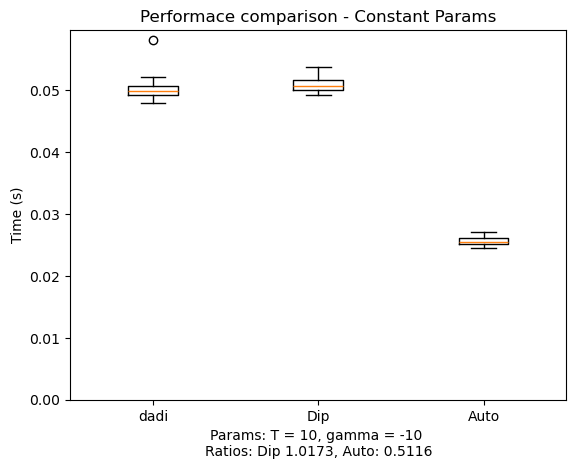

In [ ]:
# Benchmarking - Constant Params, Both Coefficient and Branching Methods
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)

ploidyflag = PolyInt.PloidyType.DIPLOID
ploidyflag_auto = PolyInt.PloidyType.AUTO
T = 10
gamma = -10
h = 0.5
sel_dict = {'gamma': gamma, 'h': h}
sel_dict_auto = {'gamma': gamma} # this will return additivity
iterations = 100

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
poly_auto_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi_dadi = dadi.Integration.one_pop(phi, xx, T=T, theta0=1, gamma=gamma, h=h)
    end = time.perf_counter()
    dadi_perf[i] = end - start

    start = time.perf_counter()
    phi_poly = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag, sel_dict=sel_dict, theta0=1)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi_poly_auto = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag_auto, sel_dict=sel_dict_auto, theta0=1)
    end = time.perf_counter()
    poly_auto_perf[i] = end - start

# Plot boxplot of performance
performance = [dadi_perf, poly_perf, poly_auto_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(poly_auto_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', 'Dip', 'Auto'])
plt.title("Performace comparison - Constant Params")
plt.ylabel("Time (s)")
plt.xlabel(
    f"Params: T = {T}, gamma = {gamma} \n"
    f"Ratios: Dip {ratio_dip:.4f}, Auto: {ratio_auto:.4f}"
)
plt.ylim(ymin=0)


### Then, we will test PolyInt vs. dadi for Variable Nu 
This will call the C and Cython integration functions.

(0.0, 1.0284706603968516)

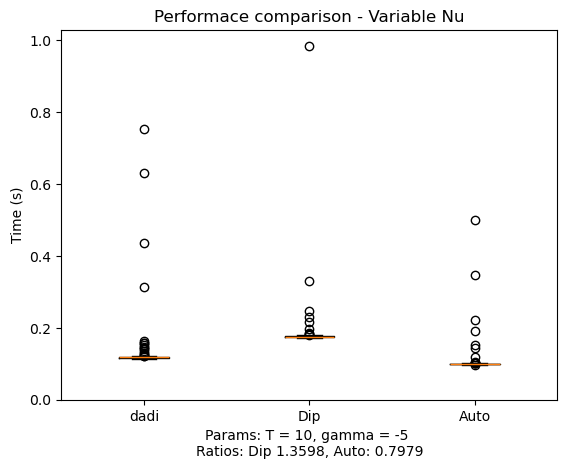

In [4]:
# Benchmarking - Variable Params, Both Coefficient and Branching Methods
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)

ploidyflag = PolyInt.PloidyType.DIPLOID
ploidyflag_auto = PolyInt.PloidyType.AUTO
T = 10
gamma = -5
h = 0.5
sel_dict = {'gamma': gamma, 'h': h}
sel_dict_auto = {'gamma1': gamma/4, 'gamma2': gamma/2, 'gamma3':3*gamma/4, 'gamma4':gamma} # need to create a wrapper for this
iterations = 100
nu = 1.5
nu_func = lambda t: np.exp(np.log(nu)*t/T)

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
poly_auto_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi_dadi = dadi.Integration.one_pop(phi, xx, T=T, theta0=1, gamma=gamma, h=h, nu=nu_func)
    end = time.perf_counter()
    dadi_perf[i] = end - start

    start = time.perf_counter()
    phi_poly = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag, sel_dict=sel_dict, theta0=1, nu=nu_func)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi_poly_auto = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag_auto, sel_dict=sel_dict_auto, theta0=1, nu=nu_func)
    end = time.perf_counter()
    poly_auto_perf[i] = end - start

# Plot boxplot of performance
performance = [dadi_perf, poly_perf, poly_auto_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(poly_auto_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', 'Dip', 'Auto'])
plt.title("Performace comparison - Variable Nu")
plt.ylabel("Time (s)")
plt.xlabel(
    f"Params: T = {T}, gamma = {gamma} \n"
    f"Ratios: Dip {ratio_dip:.4f}, Auto: {ratio_auto:.4f}"
)
plt.ylim(ymin=0)

### Now, let's see how things compare for large gammas where the timestep may be small

(0.0, 0.08949268751312048)

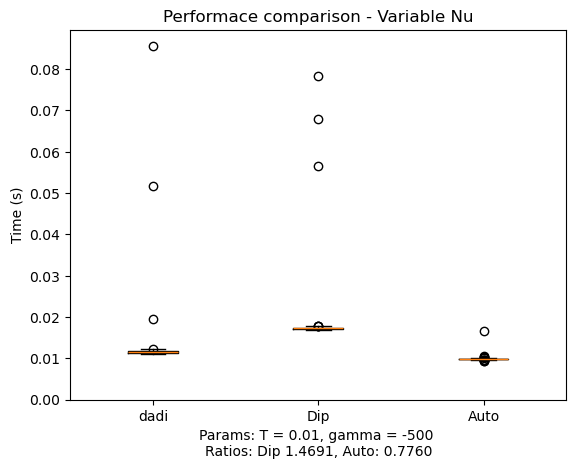

In [6]:
# Benchmarking - Variable Params, Both Coefficient and Branching Methods
xx = dadi.Numerics.default_grid(pts=101)

phi = dadi.PhiManip.phi_1D(xx)

ploidyflag = PolyInt.PloidyType.DIPLOID
ploidyflag_auto = PolyInt.PloidyType.AUTO
T = .01
gamma = -500
h = 0.5
sel_dict = {'gamma': gamma, 'h': h}
sel_dict_auto = {'gamma1': gamma/4, 'gamma2': gamma/2, 'gamma3':3*gamma/4, 'gamma4':gamma} # need to create a wrapper for this
iterations = 100
nu = 1.5
nu_func = lambda t: np.exp(np.log(nu)*t/T)

dadi_perf = np.empty(iterations)
poly_perf = np.empty(iterations)
poly_auto_perf = np.empty(iterations)
for i in range(iterations):
    start = time.perf_counter()
    phi_dadi = dadi.Integration.one_pop(phi, xx, T=T, theta0=1, gamma=gamma, h=h, nu=nu_func)
    end = time.perf_counter()
    dadi_perf[i] = end - start

    start = time.perf_counter()
    phi_poly = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag, sel_dict=sel_dict, theta0=1, nu=nu_func)
    end = time.perf_counter()
    poly_perf[i] = end - start

    start = time.perf_counter()
    phi_poly_auto = PolyInt.one_pop(phi, xx, T=T, ploidyflag=ploidyflag_auto, sel_dict=sel_dict_auto, theta0=1, nu=nu_func)
    end = time.perf_counter()
    poly_auto_perf[i] = end - start

# Plot boxplot of performance


performance = [dadi_perf, poly_perf, poly_auto_perf]

ratio_dip = np.mean(poly_perf)/np.mean(dadi_perf)
ratio_auto = np.mean(poly_auto_perf)/np.mean(dadi_perf)

plt.boxplot(performance, tick_labels=['dadi', 'Dip', 'Auto'])
plt.title("Performace comparison - Variable Nu")
plt.ylabel("Time (s)")
plt.xlabel(
    f"Params: T = {T}, gamma = {gamma} \n"
    f"Ratios: Dip {ratio_dip:.4f}, Auto: {ratio_auto:.4f}"
    
)
plt.ylim(ymin=0)

### Let's try to see where the bottlenecks might be for the polyploid integration
An obvious first place to look are the M func computations and compute_dt functions.

The compute_dt function cannot be optimized too much, but using Horner's method for the M func improved the ratio from ~2.15 to ~1.55, which is significant. 

In [ ]:

xx = dadi.Numerics.default_grid(pts=101)
dx = np.diff(xx)

phi = dadi.PhiManip.phi_1D(xx)

gamma = -10
h = 0.5
sel1 = np.array([gamma, h, 0, 0])
sel2 = np.array([gamma/4, gamma/2, 3*gamma/4, gamma])
nu = 1.
ms = [0]

iterations = 100000

M_dip = np.empty(iterations)
M_auto = np.empty(iterations)
dt_dip = np.empty(iterations)
dt_auto = np.empty(iterations)

for i in range(iterations):
    start = time.perf_counter()
    M_val = PolyInt._Mfunc1D(xx, sel1[0], sel1[1])
    end = time.perf_counter()
    M_dip[i] = end - start

    start = time.perf_counter()
    dt_val = PolyInt._compute_dt(dx, nu, ms, sel1)
    end = time.perf_counter()
    dt_dip[i] = end - start

    start = time.perf_counter()
    M_val = PolyInt._Mfunc1D_auto(xx, sel2)
    end = time.perf_counter()
    M_auto[i] = end - start

    start = time.perf_counter()
    dt_val = PolyInt._compute_dt_auto(dx, nu, ms, gamma/4, gamma/2, 3*gamma/4, gamma)
    end = time.perf_counter()
    dt_auto[i] = end - start


print(f"Diploid M avg.: {np.mean(M_dip)} \n" 
      f"Auto M avg.: {np.mean(M_auto)} \n"
      f"M Ratio: {np.mean(M_auto)/np.mean(M_dip)}")

print(f"Diploid dt avg.: {np.mean(dt_dip)} \n" 
      f"Auto dt avg.: {np.mean(dt_auto)} \n"
      f"dt Ratio: {np.mean(dt_auto)/np.mean(dt_dip)}")

# Note: From testing the C versions of the M_funcs, the auto version seems to be ~ 1.2x slower
# than the diploid C version... so the C performance is less of a bottleneck than this makes it seem


Diploid M avg.: 2.336692122044042e-06 
Auto M avg.: 3.718882133252919e-06 
M Ratio: 1.5915156721630037
Diploid dt avg.: 1.3665240234695374e-06 
Auto dt avg.: 2.293784620705992e-06 
dt Ratio: 1.6785541866158966


## Example Usage of PloidyType Class
Simple walkthrough of how to use the PloidyType class to specify a population's ploidy type.

In [ ]:
dipflag = PolyInt.PloidyType.DIPLOID
print(dipflag)
print(dipflag.value)

autoflag = PolyInt.PloidyType.AUTO
print(autoflag)
print(autoflag.value)


PloidyType.DIPLOID
0
PloidyType.AUTO
1


In [ ]:
# Then, to specify the ploidy of a population we simply write
# diploids
ploidy = np.zeros(2, dtype=np.intc)
ploidy[dipflag] = 1
print(ploidy)
# autotetraploids
ploidy2 = np.zeros(2, dtype=np.intc)
ploidy2[autoflag] = 1
print(ploidy2)


[1 0]
[0 1]


In [ ]:
sel_dict = {'gamma': -4, 'h': 0.5}
sel_dict2 = {'gamma1': -1, 'gamma2': -2, 'gamma3': -3, 'gamma4': -4}

# Note: I still need to add wrappers for additive selection models 
# which take a single gamma for the autos
# I also need to add warnings for the pack_sel_params function if 
# the user inputs an incompatible sel_dict
# but, setting up the sel_dict is pretty straightforward
sel = dipflag.pack_sel_params(sel_dict)
sel2 = autoflag.pack_sel_params(sel_dict2)

print(sel)
print(sel2)
# Note: the vectors are longer because we need to support 
# allotetraploids without changing the length of the vector
# So, for Justin's allohexaploids, sel would be of length 26

[-4, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[-1, -2, -3, -4, 0.0, 0.0, 0.0, 0.0]


In [2]:
# Let's test the new functionality of the pack_sel_params method of the PloidyType class

sel_dict_dom = {'gamma': -4, 'h1': 0.2, 'h2': 0.4, 'h3': 0.6}
sel_dict_simple = {'gamma': -4}
sel_dict_extended = {'gamma1': -4, 'gamma2': -3, 'gamma3': -2, 'gamma4': -1}
sel_dict_mistyped = {'gamma': -4, 'h1': 0.2, 'h2': 0.1, 'h3': 0.3, 'h4': 0.4}

# test the pack_sel_params method
autoflag = PolyInt.PloidyType.AUTO

sel_dom = autoflag.pack_sel_params(sel_dict_dom)
print(f"sel_dom: {sel_dom}")
sel_simple = autoflag.pack_sel_params(sel_dict_simple)
print(f"sel_simple: {sel_simple}")
sel_extended = autoflag.pack_sel_params(sel_dict_extended)
print(f"sel_extended: {sel_extended}")

# put this one last because it should raise a value error
sel_mistyped = autoflag.pack_sel_params(sel_dict_mistyped)
print(f"sel_mistyped: {sel_mistyped}")

sel_dom: [-0.8, -1.6, -2.4, -4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sel_simple: [-1.0, -2.0, -3.0, -4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
sel_extended: [-4, -3, -2, -1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


ValueError: For an AUTO ploidy, the selection parameters must be specified as one of the following: 
1. 1 key: gamma 
2. 4 keys: gamma, h1, h2, h3 
3. 4 keys: gamma1, gamma2, gamma3, gamma4.

## Testing 1D integration

In [58]:
# plot a single phi

def plot_phi(phi, xx, title):
    print(phi[0:10])
    print(phi[-1])
    plt.figure()
    plt.plot(xx, phi)
    plt.xlabel('Allele Frequency')    
    plt.ylabel('Density')
    plt.title(title)
    plt.xlim(0, 1)
    plt.show()
    

[17181.23531513 17181.23531513  7905.3703672   4839.63220789
  3326.17672117  2433.36041421  1850.57723745  1444.66462007
  1149.00553621   926.56290334]
1.0


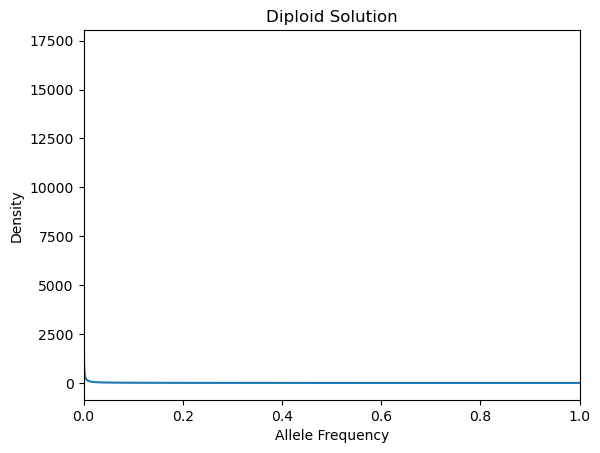

[34362.47063026 34362.47063026 15810.74073441  9679.26441579
  6652.35344235  4866.72082841  3701.15447489  2889.32924014
  2298.01107243  1853.12580668]
2.0


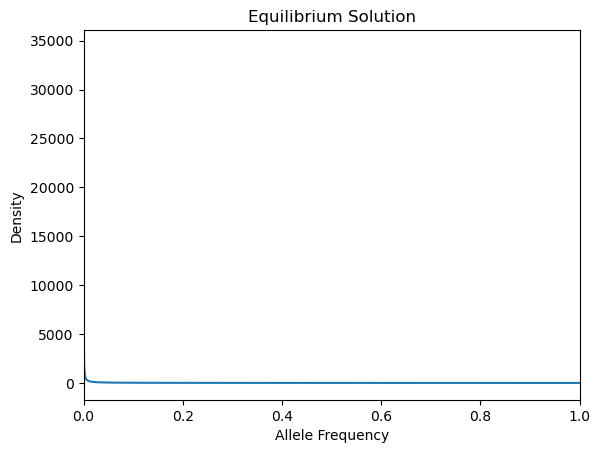

[34360.47063026 34362.47063026 15810.74073441  9679.26441579
  6652.35344235  4866.72082841  3701.15447489  2889.32924014
  2298.01107243  1853.12580668]
1.9999999999999984


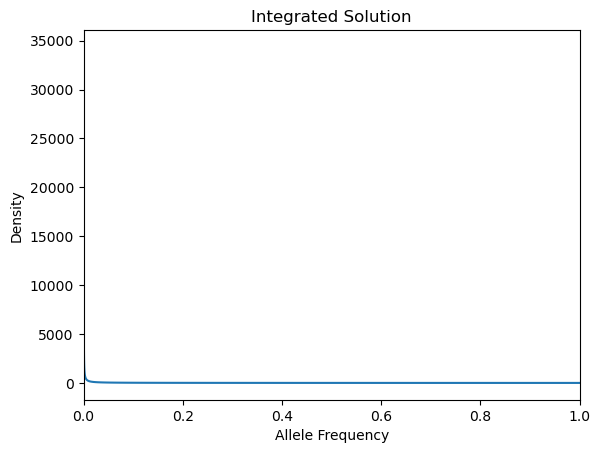

In [59]:
# without selection
xx = dadi.Numerics.default_grid(101)

phi_dip = dadi.PhiManip.phi_1D(xx, nu=1.0, theta0=1)

plot_phi(phi_dip, xx, "Diploid Solution")

phi_eq = Polyploidy.PhiManip_supp.phi_1D_autotet(xx, nu=1.0, theta0=1)

plot_phi(phi_eq, xx, "Equilibrium Solution")

auto_flag = PolyInt.PloidyType.AUTO

phi = PolyInt.one_pop(phi_eq, xx, T=100, nu=1.0, ploidyflag=auto_flag, theta0=1)

plot_phi(phi, xx, "Integrated Solution")

[34355.87122293 34355.87122293 15804.14246042  9672.66747126
  6645.75805725  4860.12727233  3694.5630638   2882.74034434
  2291.42512576  1846.54331729]
0.6003734363482562


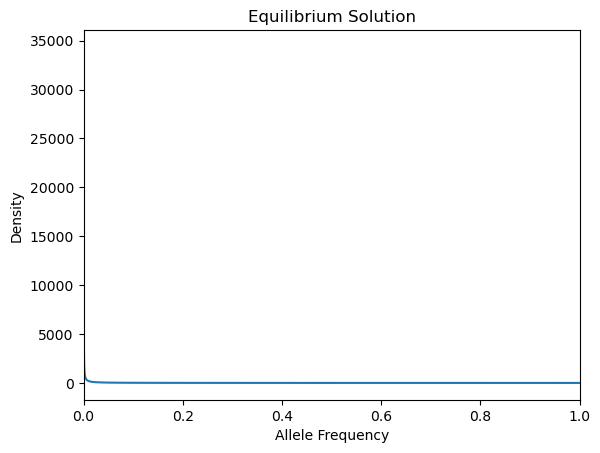

[34361.41743221 34359.41801973 15804.84644307  9672.7331982
  6645.57378708  4859.81947208  3694.18612292  2882.32177358
  2290.98042263  1846.08192183]
0.02029642580143435


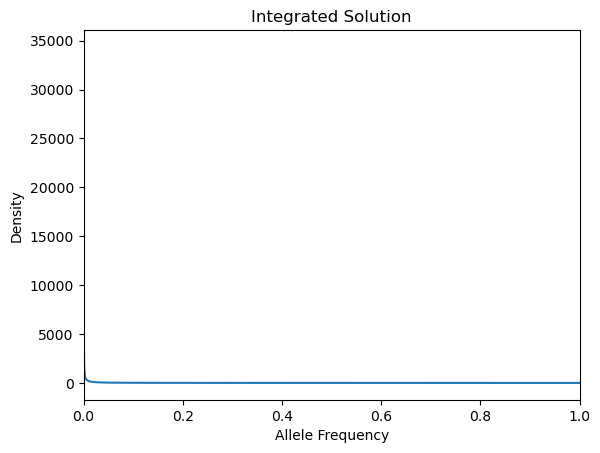

In [63]:
# with selection
xx = dadi.Numerics.default_grid(101)

phi_eq = Polyploidy.PhiManip_supp.phi_1D_autotet(xx, nu=1.0, theta0=1, 
                                                 gamma1=-0.5, gamma2=-0.75, gamma3=-0.5, gamma4=-1)

plot_phi(phi_eq, xx, "Equilibrium Solution")

sel_dict = {'gamma1': -.5, 'gamma2': -.5, 'gamma3': .5, 'gamma4': -4}

auto_flag = PolyInt.PloidyType.AUTO

phi = PolyInt.one_pop(phi_eq, xx, T=1, nu=1.0, sel_dict=sel_dict, ploidyflag=auto_flag)

plot_phi(phi, xx, "Integrated Solution")